# Questão 1


## a) 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:

# ==========================================
# 1. IMPLEMENTAÇÃO DA MLP DO ZERO (REGRESSÃO)
# ==========================================

class MLPRegressorDoZero:
    def __init__(self, input_dim, hidden_dim, alpha=0.01, beta=0.9):
        """
        input_dim: Número de atributos de entrada (8 para o dataset concrete)
        hidden_dim: Número de neurônios na camada oculta (hiperparâmetro)
        alpha: Taxa de aprendizado (learning rate)
        beta: Coeficiente de momentum
        """
        self.alpha = alpha
        self.beta = beta
        
        # Inicialização de Pesos (He/Xavier adaptado para Sigmoide)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        
        # Como é REGRESSÃO, a saída tem 1 único neurônio
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, 1))
        
        # Inicialização das matrizes de velocidade para o Momentum
        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = np.zeros_like(self.b2)

    def _sigmoide(self, z):
        # Clipping para evitar overflow numérico em valores extremos
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _derivada_sigmoide(self, a):
        # 'a' já é a saída da sigmoide: a = sigmoide(z)
        return a * (1.0 - a)

    def forward(self, X):
        """Fluxo de ida dos dados pela rede (Forward Pass)"""
        self.X = X
        # Camada Oculta
        self.z1 = np.dot(X, self.W1) + self.b1
        self.h = self._sigmoide(self.z1)
        
        # Camada de Saída (Ativação Linear para Regressão: y_hat = z2)
        self.z2 = np.dot(self.h, self.W2) + self.b2
        self.y_hat = self.z2
        return self.y_hat

    def backward(self, y_true):
        """Cálculo dos gradientes (Backpropagation)"""
        N = y_true.shape[0]
        
        # Erro na camada de saída (Regressão com Linear + MSE)
        self.d_z2 = (self.y_hat - y_true) / N
        
        # Gradientes da Camada de Saída
        self.dW2 = np.dot(self.h.T, self.d_z2)
        self.db2 = np.sum(self.d_z2, axis=0, keepdims=True)
        
        # Retropropagação do erro para a camada oculta
        self.d_h = np.dot(self.d_z2, self.W2.T)
        self.d_z1 = self.d_h * self._derivada_sigmoide(self.h)
        
        # Gradientes da Camada Oculta
        self.dW1 = np.dot(self.X.T, self.d_z1)
        self.db1 = np.sum(self.d_z1, axis=0, keepdims=True)

    def update_weights(self):
        """Atualização dos pesos utilizando SGD com Termo de Momentum"""
        self.v_W1 = self.beta * self.v_W1 + self.alpha * self.dW1
        self.W1 -= self.v_W1
        
        self.v_b1 = self.beta * self.v_b1 + self.alpha * self.db1
        self.b1 -= self.v_b1
        
        self.v_W2 = self.beta * self.v_W2 + self.alpha * self.dW2
        self.W2 -= self.v_W2
        
        self.v_b2 = self.beta * self.v_b2 + self.alpha * self.db2
        self.b2 -= self.v_b2

    def calcular_mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)


# ==========================================
# 2. FUNÇÕES PARA AS MÉTRICAS DO ITEM B)
# ==========================================

def calcular_metricas(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mre = np.mean(np.abs((y_true - y_pred) / y_true))
    return rmse, mae, mre


# ==========================================
# 3. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==========================================

# Caminho para a pasta "dados"
CAMINHO_DADOS = os.path.join("dados", "concrete.csv")

# header=None adicionado para não perder a primeira linha de dados
df = pd.read_csv(CAMINHO_DADOS, header=None)

# Separando Atributos (X) e Alvo (y)
X_raw = df.iloc[:, :8].to_numpy()
y_raw = df.iloc[:, 8].to_numpy().reshape(-1, 1)

# Embaralhar os dados aleatoriamente
np.random.seed(42)  
indices = np.arange(X_raw.shape[0])
np.random.shuffle(indices)

X_shuffled = X_raw[indices]
y_shuffled = y_raw[indices]

# Divisão dos dados: 60% treino, 20% validação, 20% teste
N = X_shuffled.shape[0]
limite_treino = int(0.6 * N)
limite_val = int(0.8 * N)

X_train_raw = X_shuffled[:limite_treino]
y_train = y_shuffled[:limite_treino]

X_val_raw = X_shuffled[limite_treino:limite_val]
y_val = y_shuffled[limite_treino:limite_val]

X_test_raw = X_shuffled[limite_val:]
y_test = y_shuffled[limite_val:]

# PADRONIZAÇÃO COMPLETAMENTE MANUAL (Z-Score) VIA NUMPY
mean_train = np.mean(X_train_raw, axis=0)
std_train = np.std(X_train_raw, axis=0)
std_train[std_train == 0] = 1e-8  

X_train = (X_train_raw - mean_train) / std_train
X_val = (X_val_raw - mean_train) / std_train
X_test = (X_test_raw - mean_train) / std_train




Treinamento

In [3]:
# ==========================================
# 4. PROCESSO DE TREINAMENTO (MINIBATCH SGD)
# ==========================================

# Hiperparâmetros recomendados para boa convergência
EPOCHS = 300
BATCH_SIZE = 32
HIDDEN_NEURONS = 16
LEARNING_RATE = 0.03
MOMENTUM_COEF = 0.9

# Inicializando o modelo do zero
modelo = MLPRegressorDoZero(
    input_dim=8, 
    hidden_dim=HIDDEN_NEURONS, 
    alpha=LEARNING_RATE, 
    beta=MOMENTUM_COEF
)

# Históricos para o gráfico
historico_custo_treino = []
historico_custo_val = []

print("Iniciando o treinamento da rede neural (100% código próprio)...")

for epoca in range(EPOCHS):
    # Re-embaralhar os dados de treino a cada época para um SGD legítimo
    indices_treino = np.arange(X_train.shape[0])
    np.random.shuffle(indices_treino)
    X_train_s, y_train_s = X_train[indices_treino], y_train[indices_treino]
    
    # Execução em minibatches
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        X_batch = X_train_s[i : i + BATCH_SIZE]
        y_batch = y_train_s[i : i + BATCH_SIZE]
        
        modelo.forward(X_batch)
        modelo.backward(y_batch)
        modelo.update_weights()
        
    # Fim da época: computa o custo total para os gráficos
    pred_treino_total = modelo.forward(X_train)
    custo_treino = modelo.calcular_mse(y_train, pred_treino_total)
    historico_custo_treino.append(custo_treino)
    
    pred_val_total = modelo.forward(X_val)
    custo_val = modelo.calcular_mse(y_val, pred_val_total)
    historico_custo_val.append(custo_val)
    
    if (epoca + 1) % 50 == 0 or epoca == 0:
        print(f"Época {epoca+1:03d}/{EPOCHS} -> MSE Treino: {custo_treino:.4f} | MSE Validação: {custo_val:.4f}")

print("\nTreinamento concluído com sucesso!")



Iniciando o treinamento da rede neural (100% código próprio)...
Época 001/300 -> MSE Treino: 146.4613 | MSE Validação: 132.0434
Época 050/300 -> MSE Treino: 27.9945 | MSE Validação: 51.6547
Época 100/300 -> MSE Treino: 26.2517 | MSE Validação: 51.0063
Época 150/300 -> MSE Treino: 23.4467 | MSE Validação: 48.3767
Época 200/300 -> MSE Treino: 21.6240 | MSE Validação: 50.1424
Época 250/300 -> MSE Treino: 20.4882 | MSE Validação: 50.7157
Época 300/300 -> MSE Treino: 20.6755 | MSE Validação: 52.2909

Treinamento concluído com sucesso!


## b) Exibição dos resultados


CONJUNTO     | RMSE       | MAE        | MRE       
Treino       | 4.5470     | 3.5279     | 0.1283    
Validação    | 7.2312     | 5.5118     | 0.2117    
Teste        | 6.3896     | 5.0127     | 0.1822    


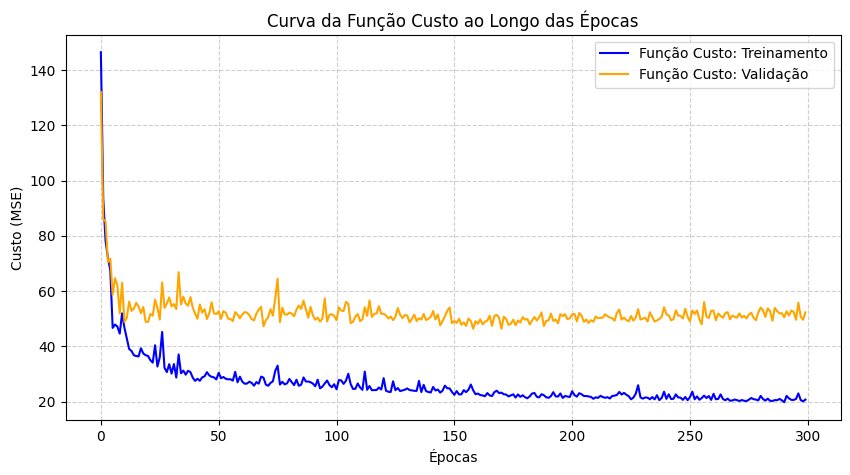

In [4]:
# ==========================================
# 5. EXIBIÇÃO DOS RESULTADOS EXIGIDOS
# ==========================================

# Predições Finais
preds_train = modelo.forward(X_train)
preds_val = modelo.forward(X_val)
preds_test = modelo.forward(X_test)

# Cálculo das métricas para cada conjunto
metrics_train = calcular_metricas(y_train, preds_train)
metrics_val = calcular_metricas(y_val, preds_val)
metrics_test = calcular_metricas(y_test, preds_test)

# Print das Tabelas de Métricas (Item b)
print("\n" + "="*50)
print(f"{'CONJUNTO':<12} | {'RMSE':<10} | {'MAE':<10} | {'MRE':<10}")
print("="*50)
print(f"{'Treino':<12} | {metrics_train[0]:<10.4f} | {metrics_train[1]:<10.4f} | {metrics_train[2]:<10.4f}")
print(f"{'Validação':<12} | {metrics_val[0]:<10.4f} | {metrics_val[1]:<10.4f} | {metrics_val[2]:<10.4f}")
print(f"{'Teste':<12} | {metrics_test[0]:<10.4f} | {metrics_test[1]:<10.4f} | {metrics_test[2]:<10.4f}")
print("="*50)

# Geração do Gráfico das Curvas de Custo (Item b)
plt.figure(figsize=(10, 5))
plt.plot(historico_custo_treino, label='Função Custo: Treinamento', color='blue')
plt.plot(historico_custo_val, label='Função Custo: Validação', color='orange')
plt.title('Curva da Função Custo ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Custo (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Questão 2

## a)

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# ==========================================
# 1. IMPLEMENTAÇÃO DA MLP DO ZERO (CLASSIFICAÇÃO)
# ==========================================

class MLPClassifierDoZero:
    def __init__(self, input_dim, hidden_dim, output_dim, alpha=0.01, beta=0.9):
        """
        input_dim: 18 (atributos da silhueta)
        hidden_dim: Neurônios na camada oculta
        output_dim: 4 (número de classes: bus, opel, saab, van)
        """
        self.alpha = alpha
        self.beta = beta
        
        # Inicialização de Pesos (He/Xavier)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
        # Matrizes de velocidade para o Momentum
        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = np.zeros_like(self.b2)

    def _sigmoide(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _derivada_sigmoide(self, a):
        return a * (1.0 - a)

    def _softmax(self, z):
        # Subtrai o max de cada linha para estabilidade numérica 
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        """Fluxo de ida (Forward Pass)"""
        self.X = X
        # Camada Oculta (Ativação Sigmoide)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.h = self._sigmoide(self.z1)
        
        # Camada de Saída (Ativação Softmax para Multiclasse)
        self.z2 = np.dot(self.h, self.W2) + self.b2
        self.y_hat = self._softmax(self.z2)
        return self.y_hat

    def backward(self, y_true_onehot):
        """Retropropagação (Backpropagation)"""
        N = y_true_onehot.shape[0]
        
        # Gradiente simplificado para Softmax + Cross-Entropy Loss
        self.d_z2 = (self.y_hat - y_true_onehot) / N
        
        # Gradientes da Camada de Saída
        self.dW2 = np.dot(self.h.T, self.d_z2)
        self.db2 = np.sum(self.d_z2, axis=0, keepdims=True)
        
        # Propagação do erro para a camada oculta
        self.d_h = np.dot(self.d_z2, self.W2.T)
        self.d_z1 = self.d_h * self._derivada_sigmoide(self.h)
        
        # Gradientes da Camada Oculta
        self.dW1 = np.dot(self.X.T, self.d_z1)
        self.db1 = np.sum(self.d_z1, axis=0, keepdims=True)

    def update_weights(self):
        """Atualização de pesos com Momentum"""
        self.v_W1 = self.beta * self.v_W1 + self.alpha * self.dW1
        self.W1 -= self.v_W1
        self.v_b1 = self.beta * self.v_b1 + self.alpha * self.db1
        self.b1 -= self.v_b1
        
        self.v_W2 = self.beta * self.v_W2 + self.alpha * self.dW2
        self.W2 -= self.v_W2
        self.v_b2 = self.beta * self.v_b2 + self.alpha * self.db2
        self.b2 -= self.v_b2

    def calcular_cross_entropy(self, y_true_onehot, y_pred_prob):
        """Calcula o custo usando Entropia Cruzada"""
        epsilon = 1e-15  # Evita log(0)
        y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)
        return -np.mean(np.sum(y_true_onehot * np.log(y_pred_prob), axis=1))


# ==========================================
# 2. ENCODING E MÉTRICAS MANUAIS (SEM SKLEARN)
# ==========================================

def para_one_hot(y_str, classes):
    """Transforma labels de texto em matriz One-Hot Encoding"""
    mapeamento = {classe: i for i, classe in enumerate(classes)}
    y_int = np.array([mapeamento[label] for label in y_str])
    one_hot = np.zeros((len(y_int), len(classes)))
    one_hot[np.arange(len(y_int)), y_int] = 1
    return one_hot, y_int

def gerar_matriz_confusao(y_true, y_pred, num_classes):
    """Gera uma matriz de confusão de tamanho (num_classes, num_classes)"""
    matriz = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        matriz[t, p] += 1
    return matriz

def calcular_metricas_classificacao(matriz_confusao):
    """Calcula acurácia, precisão macro, revocação macro e F1-score macro"""
    num_classes = matriz_confusao.shape[0]
    total_amostras = np.sum(matriz_confusao)
    
    # Acurácia Global
    acuracia = np.trace(matriz_confusao) / total_amostras
    
    precisoes = []
    revocacoes = []
    
    for i in range(num_classes):
        tp = matriz_confusao[i, i]
        fp = np.sum(matriz_confusao[:, i]) - tp
        fn = np.sum(matriz_confusao[i, :]) - tp
        
        precisao_c = tp / (tp + fp) if (tp + fp) > 0 else 0
        revocacao_c = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        precisoes.append(precisao_c)
        revocacoes.append(revocacao_c)
        
    # Médias Macro
    precisao_macro = np.mean(precisoes)
    revocacao_macro = np.mean(revocacoes)
    
    if (precisao_macro + revocacao_macro) > 0:
        f1_macro = 2 * (precisao_macro * revocacao_macro) / (precisao_macro + revocacao_macro)
    else:
        f1_macro = 0
        
    return acuracia, precisao_macro, revocacao_macro, f1_macro


# ==========================================
# 3. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==========================================

CAMINHO_DADOS = os.path.join("dados", "vehicle.csv")

df = pd.read_csv(CAMINHO_DADOS, header=None)

X_raw = df.iloc[:, :18].to_numpy()
y_raw_str = df.iloc[:, 18].to_numpy()

# Identifica as classes únicas ordenadas
classes_unicas = sorted(list(set(y_raw_str))) # ['bus', 'opel', 'saab', 'van']

# Codifica os alvos
y_onehot_all, y_int_all = para_one_hot(y_raw_str, classes_unicas)

# Embaralhamento aleatório dos dados
np.random.seed(42)
indices = np.arange(X_raw.shape[0])
np.random.shuffle(indices)

X_shuffled = X_raw[indices]
y_onehot_shuffled = y_onehot_all[indices]
y_int_shuffled = y_int_all[indices]

# Divisão: 60% treino, 20% validação, 20% teste
N = X_shuffled.shape[0]
limite_treino = int(0.6 * N)
limite_val = int(0.8 * N)

X_train_raw = X_shuffled[:limite_treino]
y_train_oh = y_onehot_shuffled[:limite_treino]
y_train_int = y_int_shuffled[:limite_treino]

X_val_raw = X_shuffled[limite_treino:limite_val]
y_val_oh = y_onehot_shuffled[limite_treino:limite_val]
y_val_int = y_int_shuffled[limite_treino:limite_val]

X_test_raw = X_shuffled[limite_val:]
y_test_oh = y_onehot_shuffled[limite_val:]
y_test_int = y_int_shuffled[limite_val:]

# Padronização Z-score manual usando médias do Treino
mean_train = np.mean(X_train_raw, axis=0)
std_train = np.std(X_train_raw, axis=0)
std_train[std_train == 0] = 1e-8

X_train = (X_train_raw - mean_train) / std_train
X_val = (X_val_raw - mean_train) / std_train
X_test = (X_test_raw - mean_train) / std_train


Treinamento

In [8]:
# ==========================================
# 4. PROCESSO DE TREINAMENTO (MINIBATCH SGD)
# ==========================================

# Hiperparâmetros calibrados para a classificação
EPOCHS = 400
BATCH_SIZE = 32
HIDDEN_NEURONS = 32
LEARNING_RATE = 0.02
MOMENTUM_COEF = 0.9

modelo = MLPClassifierDoZero(
    input_dim=18, 
    hidden_dim=HIDDEN_NEURONS, 
    output_dim=len(classes_unicas),
    alpha=LEARNING_RATE, 
    beta=MOMENTUM_COEF
)

historico_custo_treino = []
historico_custo_val = []

print("Iniciando o treinamento para classificação de veículos...")

for epoca in range(EPOCHS):
    # Re-embaralhar treino a cada época
    indices_treino = np.arange(X_train.shape[0])
    np.random.shuffle(indices_treino)
    X_train_s = X_train[indices_treino]
    y_train_oh_s = y_train_oh[indices_treino]
    
    # Execução em Minibatches
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        X_batch = X_train_s[i : i + BATCH_SIZE]
        y_batch_oh = y_train_oh_s[i : i + BATCH_SIZE]
        
        modelo.forward(X_batch)
        modelo.backward(y_batch_oh)
        modelo.update_weights()
        
    # Histórico de custos (Cross-Entropy) ao fim da época
    prob_treino = modelo.forward(X_train)
    custo_treino = modelo.calcular_cross_entropy(y_train_oh, prob_treino)
    historico_custo_treino.append(custo_treino)
    
    prob_val = modelo.forward(X_val)
    custo_val = modelo.calcular_cross_entropy(y_val_oh, prob_val)
    historico_custo_val.append(custo_val)
    
    if (epoca + 1) % 50 == 0 or epoca == 0:
        print(f"Época {epoca+1:03d}/{EPOCHS} -> Custo Treino: {custo_treino:.4f} | Custo Validação: {custo_val:.4f}")

print("\nTreinamento concluído!")



Iniciando o treinamento para classificação de veículos...
Época 001/400 -> Custo Treino: 1.3375 | Custo Validação: 1.4038
Época 050/400 -> Custo Treino: 0.4171 | Custo Validação: 0.5594
Época 100/400 -> Custo Treino: 0.3107 | Custo Validação: 0.4839
Época 150/400 -> Custo Treino: 0.2514 | Custo Validação: 0.4759
Época 200/400 -> Custo Treino: 0.2069 | Custo Validação: 0.5003
Época 250/400 -> Custo Treino: 0.1739 | Custo Validação: 0.5283
Época 300/400 -> Custo Treino: 0.1492 | Custo Validação: 0.5686
Época 350/400 -> Custo Treino: 0.1279 | Custo Validação: 0.6016
Época 400/400 -> Custo Treino: 0.1114 | Custo Validação: 0.6276

Treinamento concluído!


## b) Reportes


CONJUNTO     | ACURÁCIA  | PRECISÃO (M) | REVOCAÇÃO (M) | F1-SCORE
Treino       | 0.9763    | 0.9765       | 0.9745        | 0.9755  
Validação    | 0.7929    | 0.8124       | 0.7923        | 0.8022  
Teste        | 0.7118    | 0.7489       | 0.7507        | 0.7498  

Matriz de Confusão (Conjunto de Teste):
Classes de referência: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
[[34  0  1  1]
 [ 1 30 30  1]
 [ 1 12 22  0]
 [ 0  1  1 35]]


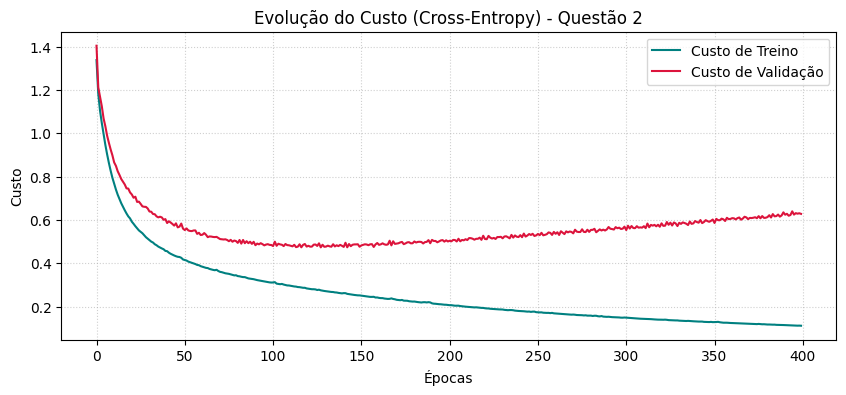

In [9]:
# ==========================================
# 5. AVALIAÇÃO DAS MÉTRICAS E MATRIZ DE CONFUSÃO
# ==========================================

# Transforma as probabilidades preditas de volta para inteiros de classe (Argmax)
pred_train_int = np.argmax(modelo.forward(X_train), axis=1)
pred_val_int = np.argmax(modelo.forward(X_val), axis=1)
pred_test_int = np.argmax(modelo.forward(X_test), axis=1)

# Matrizes de confusão
mc_train = gerar_matriz_confusao(y_train_int, pred_train_int, len(classes_unicas))
mc_val = gerar_matriz_confusao(y_val_int, pred_val_int, len(classes_unicas))
mc_test = gerar_matriz_confusao(y_test_int, pred_test_int, len(classes_unicas))

# Cálculo das métricas solicitadas
metrics_train = calcular_metricas_classificacao(mc_train)
metrics_val = calcular_metricas_classificacao(mc_val)
metrics_test = calcular_metricas_classificacao(mc_test)

# Exibição das Tabelas de Métricas (Item b)
print("\n" + "="*65)
print(f"{'CONJUNTO':<12} | {'ACURÁCIA':<9} | {'PRECISÃO (M)':<12} | {'REVOCAÇÃO (M)':<13} | {'F1-SCORE':<8}")
print("="*65)
print(f"{'Treino':<12} | {metrics_train[0]:<9.4f} | {metrics_train[1]:<12.4f} | {metrics_train[2]:<13.4f} | {metrics_train[3]:<8.4f}")
print(f"{'Validação':<12} | {metrics_val[0]:<9.4f} | {metrics_val[1]:<12.4f} | {metrics_val[2]:<13.4f} | {metrics_val[3]:<8.4f}")
print(f"{'Teste':<12} | {metrics_test[0]:<9.4f} | {metrics_test[1]:<12.4f} | {metrics_test[2]:<13.4f} | {metrics_test[3]:<8.4f}")
print("="*65)

# Exibição Gráfica da Matriz de Confusão no Teste (Item b)
print("\nMatriz de Confusão (Conjunto de Teste):")
print(f"Classes de referência: {classes_unicas}")
print(mc_test)

# Plot das curvas de custo
plt.figure(figsize=(10, 4))
plt.plot(historico_custo_treino, label='Custo de Treino', color='teal')
plt.plot(historico_custo_val, label='Custo de Validação', color='crimson')
plt.title('Evolução do Custo (Cross-Entropy) - Questão 2')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()